<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">1- Importation des bibliothèques</h2>
</div>

In [151]:
import pandas as pd     
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor ,plot_tree
from statistics import linear_regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler , RobustScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import math
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer, OneHotEncoder, LabelEncoder , OrdinalEncoder
from sklearn.model_selection import train_test_split
import re
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import KNNImputer
from sklearn.compose import ColumnTransformer 
import math
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import joblib

In [75]:
df = pd.read_csv('mubawab_listings_clean.csv')
df.head()

,Type,Localisation,Price,Area,Rooms,Bedrooms,Bathrooms,Floor,Other_tags,Price_m2
0,Appartements,Casablanca Finance City,22000,219.0,4.0,3.0,3.0,11.0,"['Nouveau', ""Moins d'un an""]",100.456621
1,Appartements,Anfa,1230000,86.0,3.0,2.0,2.0,1.0,"['Bon état', '10-20 ans']",14302.325581
2,Appartements,La Gironde,900000,86.0,3.0,2.0,1.0,5.0,"['Bon état', '10-20 ans']",10465.116279
3,Appartements,Bourgogne Ouest,2400000,180.0,5.0,3.0,3.0,3.0,"['Bon état', '10-20 ans']",13333.333333
4,Appartements,Les princesses,1550000,120.0,5.0,3.0,2.0,5.0,"['Bon état', '5-10 ans']",12916.666667


<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">2- Compréhension des Données</h2>
</div>

In [76]:
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])

df.head(10)

Nombre de lignes : 1172
Nombre de colonnes : 10


,Type,Localisation,Price,Area,Rooms,Bedrooms,Bathrooms,Floor,Other_tags,Price_m2
0,Appartements,Casablanca Finance City,22000,219.0,4.0,3.0,3.0,11.0,"['Nouveau', ""Moins d'un an""]",100.456621
1,Appartements,Anfa,1230000,86.0,3.0,2.0,2.0,1.0,"['Bon état', '10-20 ans']",14302.325581
2,Appartements,La Gironde,900000,86.0,3.0,2.0,1.0,5.0,"['Bon état', '10-20 ans']",10465.116279
3,Appartements,Bourgogne Ouest,2400000,180.0,5.0,3.0,3.0,3.0,"['Bon état', '10-20 ans']",13333.333333
4,Appartements,Les princesses,1550000,120.0,5.0,3.0,2.0,5.0,"['Bon état', '5-10 ans']",12916.666667
5,Appartements,Bourgogne Ouest,1450000,113.0,4.0,3.0,2.0,1.0,"['Bon état', '10-20 ans']",12831.858407
6,Appartements,Triangle d'Or,4800000,245.0,4.0,3.0,3.0,3.0,"['Bon état', '10-20 ans']",19591.836735
7,Appartements,Anassi,330000,50.0,3.0,2.0,1.0,1.0,"['Bon état', '5-10 ans']",6600.000000
8,Villas,Californie,7500000,400.0,8.0,5.0,4.0,0.0,['Bon état'],18750.000000
9,Appartements,Maârif,1750000,113.0,3.0,2.0,2.0,4.0,"['Nouveau', '1-5 ans']",15486.725664


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1172 entries, 0 to 1171
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Type          1172 non-null   object 
 1   Localisation  1172 non-null   object 
 2   Price         1172 non-null   int64  
 3   Area          1172 non-null   float64
 4   Rooms         1172 non-null   float64
 5   Bedrooms      1172 non-null   float64
 6   Bathrooms     1172 non-null   float64
 7   Floor         1172 non-null   float64
 8   Other_tags    1172 non-null   object 
 9   Price_m2      1172 non-null   float64
dtypes: float64(6), int64(1), object(3)
memory usage: 91.7+ KB


In [78]:
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['Type', 'Localisation', 'Other_tags'], dtype='object')

In [79]:
numeric_cols = df.select_dtypes(include=['number']).columns
numeric_cols

Index(['Price', 'Area', 'Rooms', 'Bedrooms', 'Bathrooms', 'Floor', 'Price_m2'], dtype='object')

In [80]:
df['Type'].unique()

array(['Appartements', 'Villas', 'Riad', 'Maisons'], dtype=object)

In [81]:
df['Localisation'].unique()

array(['Casablanca Finance City', 'Anfa', 'La Gironde', 'Bourgogne Ouest',
       'Les princesses', "Triangle d'Or", 'Anassi', 'Californie',
       'Maârif', 'Racine', 'Gauthier', 'Val Fleury', 'Sidi Maarouf',
       'Ain Diab', 'Racine Extension', 'Palmier', 'Oasis',
       'CIL (Hay Salam)', 'Les Crêtes', 'Bourgogne Est',
       'Maârif Extension', 'Ain Diab Extension', 'Hay Alamal',
       'Mers Sultan', 'Beauséjour', 'Laymoune',
       'Longchamps (Hay Al Hanâa)', 'El Manar - El Hank', 'Oulfa',
       'Les Hôpitaux', 'Derb Ghalef', 'Aïn Sebaâ', 'Hay Alhoda', 'Polo',
       'Hay Zobir', 'Foncière', 'Anfa Supérieur', 'Benjdia', 'Ain Chock',
       'Burger', 'Plateau (Al Batha)', 'Casablanca Marina', 'Port',
       'Hermitage', 'Lissasfa', 'Al Azhar', 'Mandarona', 'Nassim 1',
       'Ferme Bretonne (Hay Arraha)', 'Casablanca', 'Ain Borja',
       'Tantonville', 'Bernoussi', 'Belvédère', 'Centre Ville',
       'Salmia 2', 'Moulay Youssef', 'Derb Chorfa', 'Derb Loubila',
       'Sidi Mo

In [82]:
df['Other_tags'].unique()

array(['[\'Nouveau\', "Moins d\'un an"]', "['Bon état', '10-20 ans']",
       "['Bon état', '5-10 ans']", "['Bon état']",
       "['Nouveau', '1-5 ans']", "['Nouveau']",
       "['À rénover', '30-50 ans']", "['Nouveau', '5-10 ans']",
       "['Bon état', '1-5 ans']", "['À rénover', '20-30 ans']",
       "['Bon état', '20-30 ans']", '[]', "['À rénover', '10-20 ans']",
       '[\'Bon état\', "Moins d\'un an"]', "['À rénover']",
       "['Nouveau', '10-20 ans']", "['À rénover', '5-10 ans']",
       "['Bon état', '30-50 ans']", "['Nouveau', '20-30 ans']",
       "['À rénover', '1-5 ans']", "['À rénover', '50-70 ans']"],
      dtype=object)

In [83]:
numeric_cols = df.select_dtypes(include="number").columns

print("Variables numériques :", len(numeric_cols))

df[numeric_cols].describe().T

Variables numériques : 7


,count,mean,std,min,25%,50%,75%,max
Price,1172.0,4.954876e+06,7.401288e+06,1600.000000,1.221922e+06,2.300000e+06,5.990000e+06,7.140000e+07
Area,1172.0,3.155691e+02,4.659344e+02,32.000000,9.100000e+01,1.385000e+02,3.602500e+02,5.400000e+03
Rooms,1172.0,4.814846e+00,2.298929e+00,1.000000,3.000000e+00,4.000000e+00,6.000000e+00,1.600000e+01
Bedrooms,1172.0,3.029863e+00,1.370656e+00,1.000000,2.000000e+00,3.000000e+00,4.000000e+00,1.800000e+01
Bathrooms,1172.0,2.408703e+00,1.208153e+00,1.000000,2.000000e+00,2.000000e+00,3.000000e+00,1.000000e+01
Floor,1172.0,2.277304e+00,2.206828e+00,0.000000,0.000000e+00,2.000000e+00,4.000000e+00,2.000000e+01
Price_m2,1172.0,1.568007e+04,7.721872e+03,33.333333,1.172279e+04,1.508853e+04,1.833494e+04,1.108108e+05


In [84]:
categorical_cols = df.select_dtypes(
    include=["object", "category", "bool"]
).columns

categorical_summary = pd.DataFrame({
    "dtype": df[categorical_cols].dtypes,
    "non_null": df[categorical_cols].notna().sum(),
    "missing": df[categorical_cols].isna().sum(),
    "unique": df[categorical_cols].nunique(dropna=True)
})

categorical_summary

,dtype,non_null,missing,unique
Type,object,1172,0,4
Localisation,object,1172,0,100
Other_tags,object,1172,0,21


In [85]:
categorical_cols.isnull().sum()

0

In [86]:
numeric_cols.isnull().sum()

0

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">3- data cleaning</h2>
</div>

In [87]:
print("Doublons exacts :", df.duplicated().sum())


Doublons exacts : 0


In [88]:
df = df.copy()

print("Original shape:", df.shape)
print("Cleaning copy shape:", df.shape)

Original shape: (1172, 10)
Cleaning copy shape: (1172, 10)


In [89]:
categorical_cols

Index(['Type', 'Localisation', 'Other_tags'], dtype='object')

# Other_tags  cleaning

### on va tranformer la colonne other tags de string a liste

In [90]:
import ast
df['Other_tags'] = df['Other_tags'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [91]:
tags_aplatis = df['Other_tags'].explode()
other_tags_unique = tags_aplatis.unique()
display(other_tags_unique)

other_tags_frq = tags_aplatis.value_counts()
display(other_tags_frq)

array(['Nouveau', "Moins d'un an", 'Bon état', '10-20 ans', '5-10 ans',
       '1-5 ans', 'À rénover', '30-50 ans', '20-30 ans', nan, '50-70 ans'],
      dtype=object)

Other_tags
Bon état         735
10-20 ans        313
Nouveau          292
5-10 ans         259
1-5 ans          131
À rénover         96
Moins d'un an     88
20-30 ans         76
30-50 ans         13
50-70 ans          2
Name: count, dtype: int64

In [92]:
current_state_tags = ['Bon état','Nouveau','À rénover']
current_state_tag_freq = other_tags_frq[current_state_tags]

age_tags = ["Moins d'un an",'1-5 ans','5-10 ans','10-20 ans','20-30 ans','30-50 ans','50-70 ans']
age_tag_freq = other_tags_frq[age_tags]

In [93]:

df = df.copy()

# 2. Une fonction simplifiée et plus facile à lire
def extraire_categorie(liste_annonce, categorie_tags):
    # On vérifie chaque tag de l'annonce
    for tag in liste_annonce:
        if tag in categorie_tags:
            return tag
            
    # Si la boucle se termine sans rien trouver, on renvoie "vide"
    return np.nan

# 3. On crée les deux nouvelles colonnes
df['Current_state'] = df['Other_tags'].apply(lambda x: extraire_categorie(x, current_state_tags))
df['Age']           = df['Other_tags'].apply(lambda x: extraire_categorie(x, age_tags))

C:\Users\Pc\AppData\Local\Temp\ipykernel_10924\1254540517.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Pc\AppData\Local\Temp\ipykernel_10924\1254540517.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


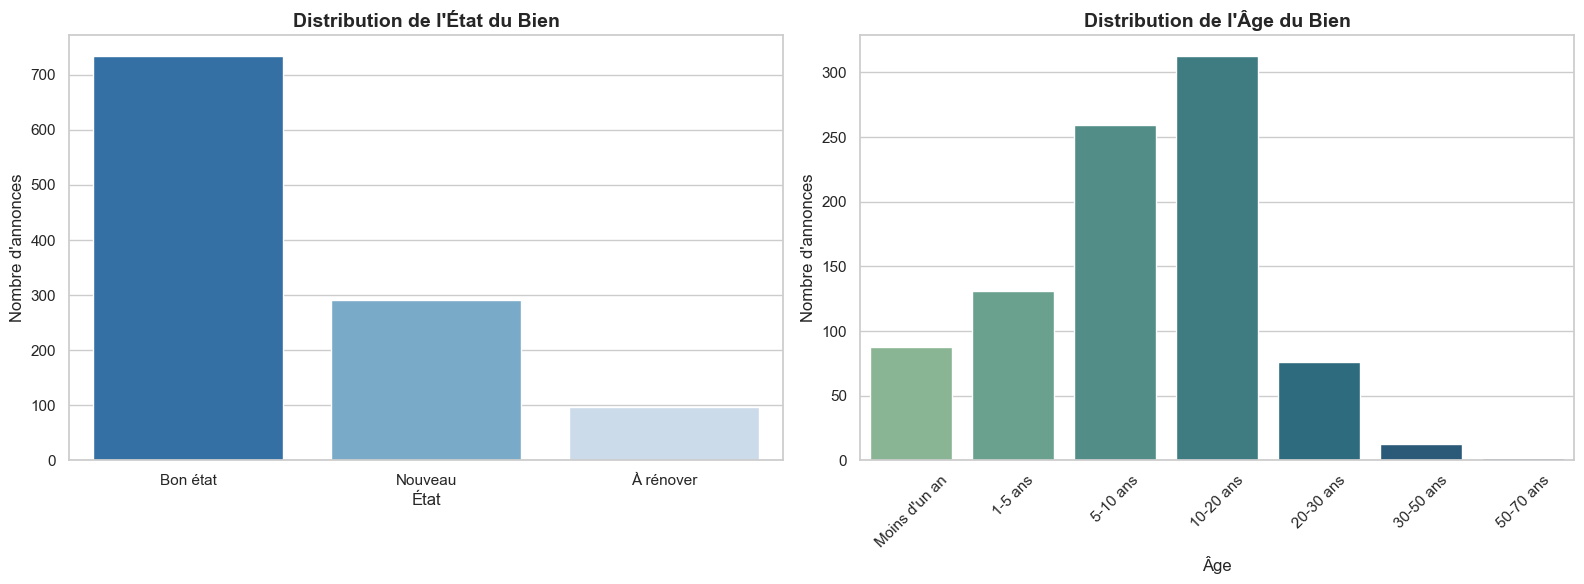

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurer le style général
sns.set_theme(style="whitegrid")

# Créer une figure avec 1 ligne et 2 colonnes (1x2)
# figsize=(16, 6) permet d'étirer l'image pour que les graphiques respirent
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Graphique 1 : Distribution de l'État ---
sns.countplot(
    data=df, 
    x='Current_state', 
    ax=axes[0], 
    palette='Blues_r', 
    order=['Bon état', 'Nouveau', 'À rénover']
)
axes[0].set_title("Distribution de l'État du Bien", fontsize=14, fontweight='bold')
axes[0].set_xlabel("État", fontsize=12)
axes[0].set_ylabel("Nombre d'annonces", fontsize=12)

# --- Graphique 2 : Distribution de l'Âge ---
age_order = ["Moins d'un an", '1-5 ans', '5-10 ans', '10-20 ans', '20-30 ans', '30-50 ans', '50-70 ans']
sns.countplot(
    data=df, 
    x='Age', 
    ax=axes[1], 
    palette='crest', 
    order=age_order
)
axes[1].set_title("Distribution de l'Âge du Bien", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Âge", fontsize=12)
axes[1].set_ylabel("Nombre d'annonces", fontsize=12)
axes[1].tick_params(axis='x', rotation=45) # Pivoter le texte pour éviter le chevauchement

# Ajuster automatiquement les marges pour que rien ne soit coupé
plt.tight_layout()

# Afficher le résultat
plt.show()

# type cleaning

### Examinons maintenant la répartition des types d'annonces.

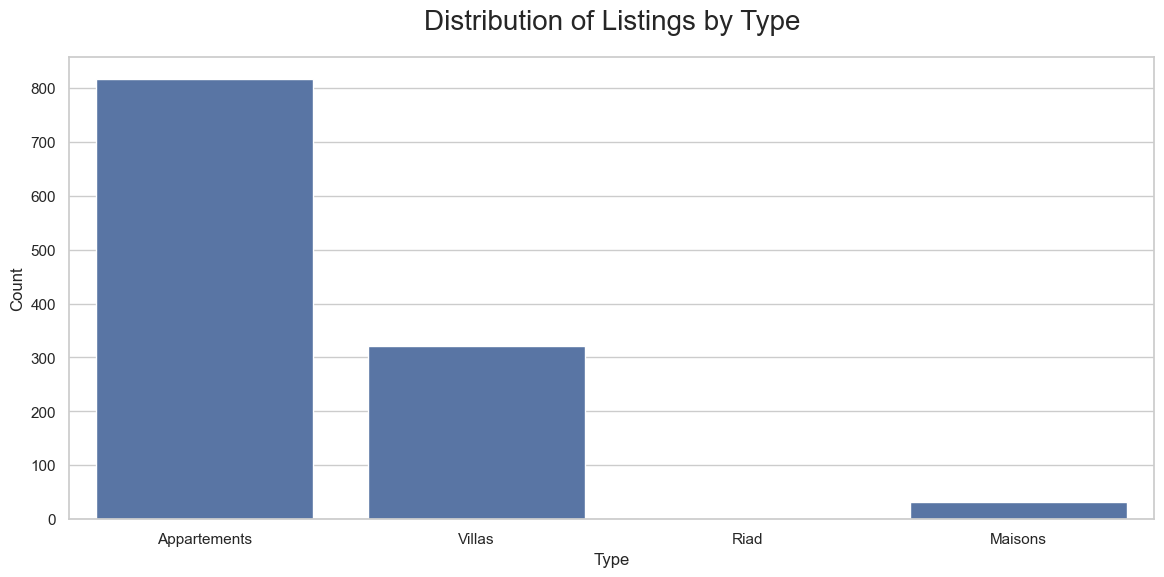

In [95]:
fig, ax = plt.subplots(figsize = (14,6))
ax = sns.countplot(x= 'Type' , data = df)
ax.set_title('Distribution of Listings by Type',fontsize = 20, pad = 20)
ax.set_xlabel('Type',fontsize = 12)
ax.set_ylabel('Count',fontsize = 12)
#plt.xticks(rotation = 90)
plt.show()

In [96]:
df['Type'].value_counts()

Type
Appartements    816
Villas          321
Maisons          32
Riad              3
Name: count, dtype: int64

In [97]:
df['Type'].isnull().sum()

0

In [98]:
df['Type'] = df['Type'].replace('Riad','Villas').replace('Maisons','Villas')

In [99]:
df['Type'].unique()

array(['Appartements', 'Villas'], dtype=object)

Nouvelle distribution des types de biens :
Type
Appartements    816
Villas          356
Name: count, dtype: int64


C:\Users\Pc\AppData\Local\Temp\ipykernel_10924\959180522.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Type', palette='Set2')


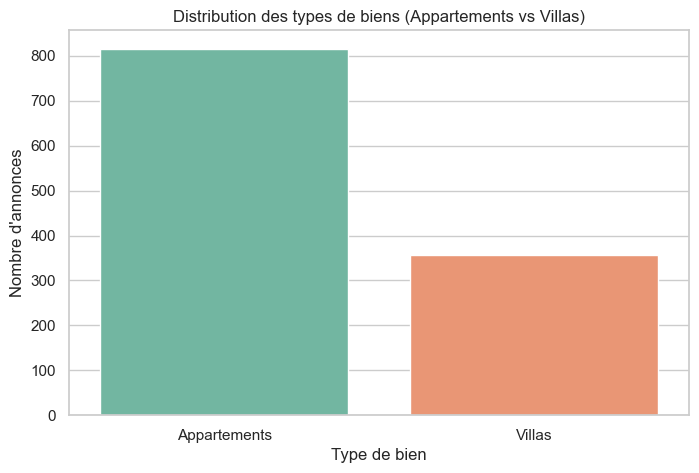

In [100]:
print("Nouvelle distribution des types de biens :")
print(df['Type'].value_counts())

# 2. Visualisation avec un graphique en barres (Countplot)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Type', palette='Set2')
plt.title("Distribution des types de biens (Appartements vs Villas)")
plt.xlabel("Type de bien")
plt.ylabel("Nombre d'annonces")
plt.show()


In [101]:
numeric_cols

Index(['Price', 'Area', 'Rooms', 'Bedrooms', 'Bathrooms', 'Floor', 'Price_m2'], dtype='object')

# Localisation cleaning 

C:\Users\Pc\AppData\Local\Temp\ipykernel_10924\3733148577.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


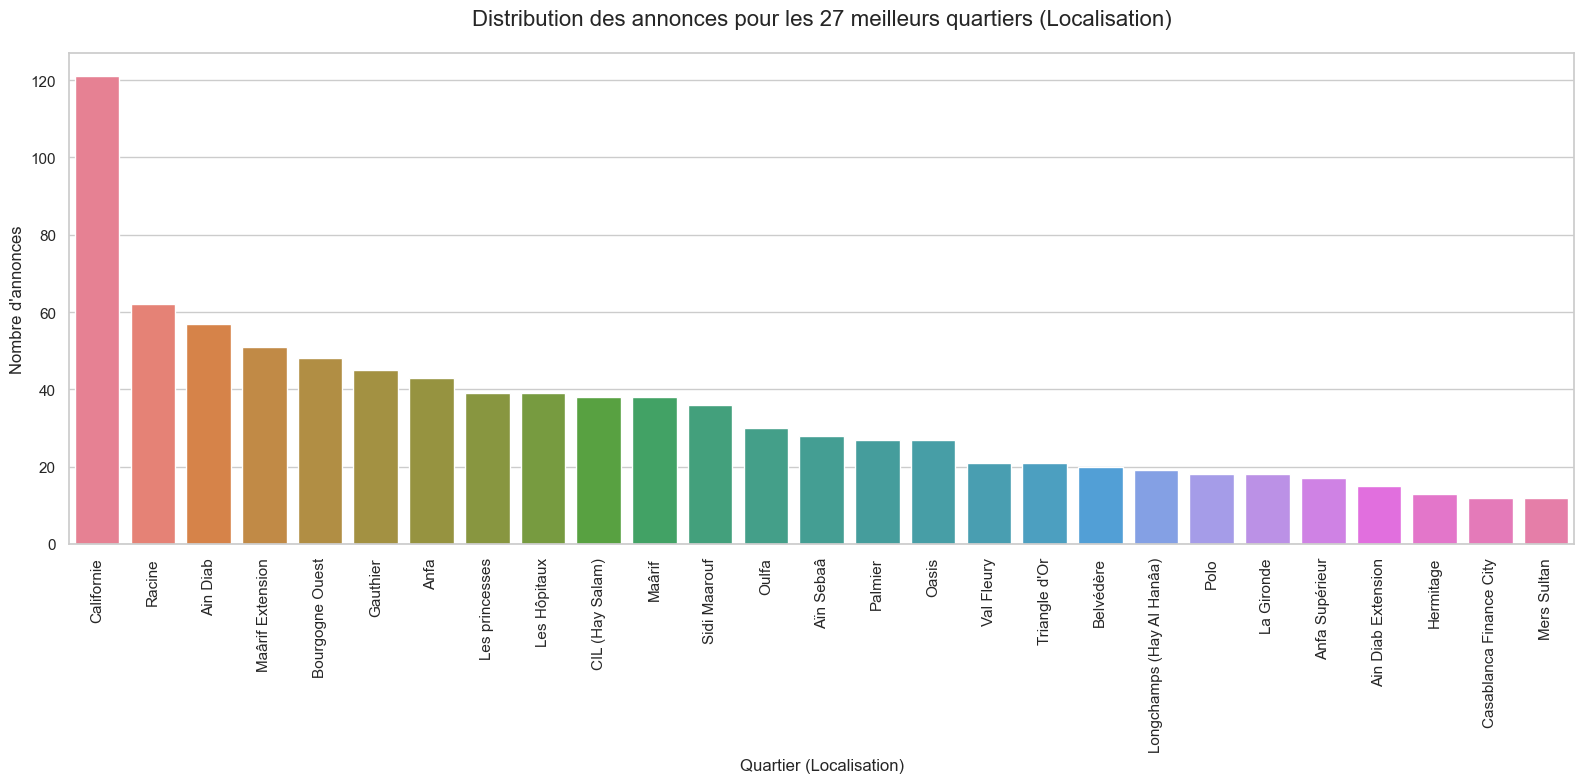

In [102]:
top_locs = df['Localisation'].value_counts().head(27)

plt.figure(figsize=(16, 8))
sns.set_style("whitegrid")

sns.barplot(
    x=top_locs.index, 
    y=top_locs.values, 
    palette="husl"  
)

plt.title('Distribution des annonces pour les 27 meilleurs quartiers (Localisation)', fontsize=16, pad=20)
plt.xlabel('Quartier (Localisation)', fontsize=12)
plt.ylabel("Nombre d'annonces", fontsize=12)

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## price cleaning 

### on va observer la correlation entre les colonnes de data avec le target price 

              Price      Area     Rooms  Bedrooms  Bathrooms     Floor  \
Price      1.000000  0.907870  0.496017  0.533170   0.589295 -0.410247   
Area       0.907870  1.000000  0.501606  0.493977   0.550690 -0.406027   
Rooms      0.496017  0.501606  1.000000  0.674138   0.631745 -0.429368   
Bedrooms   0.533170  0.493977  0.674138  1.000000   0.738318 -0.409567   
Bathrooms  0.589295  0.550690  0.631745  0.738318   1.000000 -0.383340   
Floor     -0.410247 -0.406027 -0.429368 -0.409567  -0.383340  1.000000   
Price_m2   0.236767  0.001872  0.071903  0.124002   0.165653 -0.057035   

           Price_m2  
Price      0.236767  
Area       0.001872  
Rooms      0.071903  
Bedrooms   0.124002  
Bathrooms  0.165653  
Floor     -0.057035  
Price_m2   1.000000  


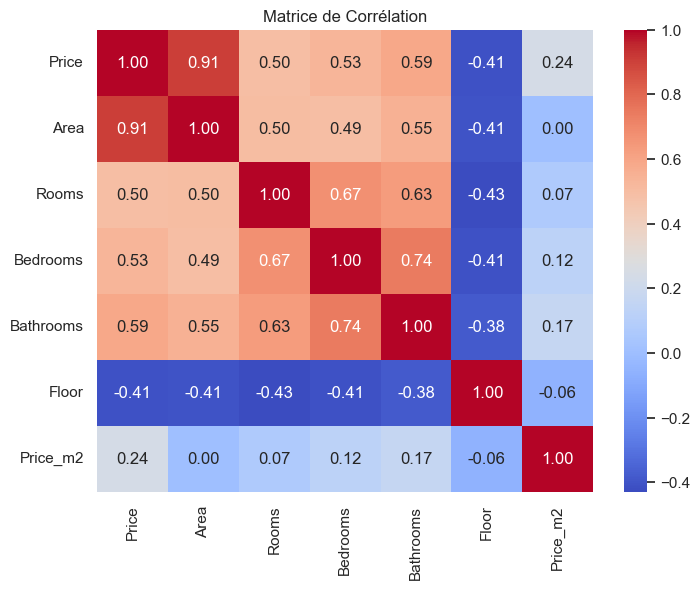

In [103]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hsab l'correlation matrix (ghir 3la l'ar9am)
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

# Rsm l'matrice b heatmap bach tban wad7a
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matrice de Corrélation")
plt.show()

## price boxplot 

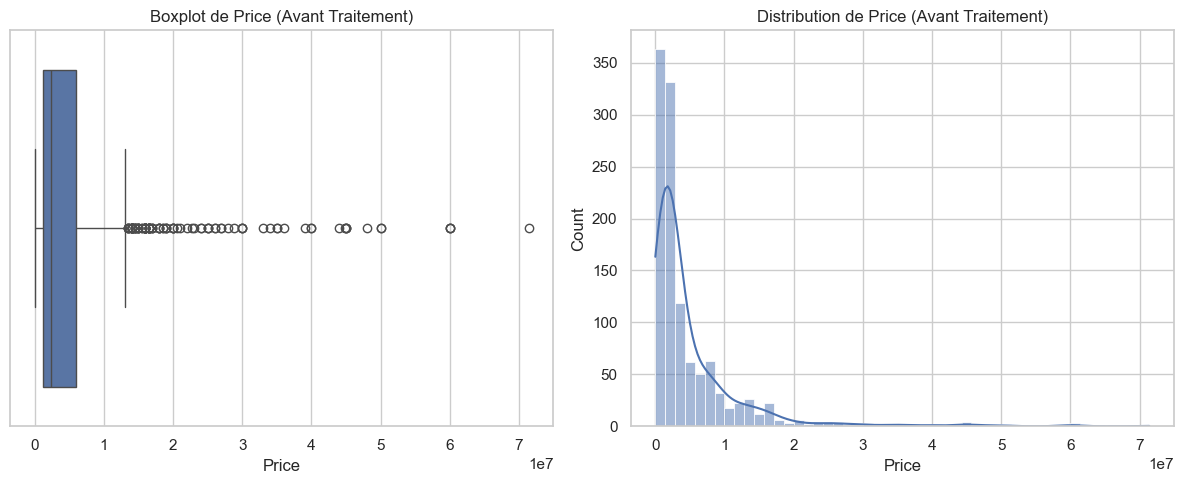

In [104]:
plt.figure(figsize=(12, 5))

# Graphique 1 : Boxplot (3la lissr)
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Price'])
plt.title('Boxplot de Price (Avant Traitement)')

# Graphique 2 : Histogramme m3a KDE (3la limn)
plt.subplot(1, 2, 2)
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Distribution de Price (Avant Traitement)')

# Ajustement w l'affichage
plt.tight_layout()
plt.show()

#### Ce que nous observons ici est une forte asymétrie positive,ce qui indique effectivement une distribution déséquilibrée des prix.
#### on peut concederer ce boit a moustache que n'a pas des vrai valeurs anmalies mais ce sont des valeurs corrects 

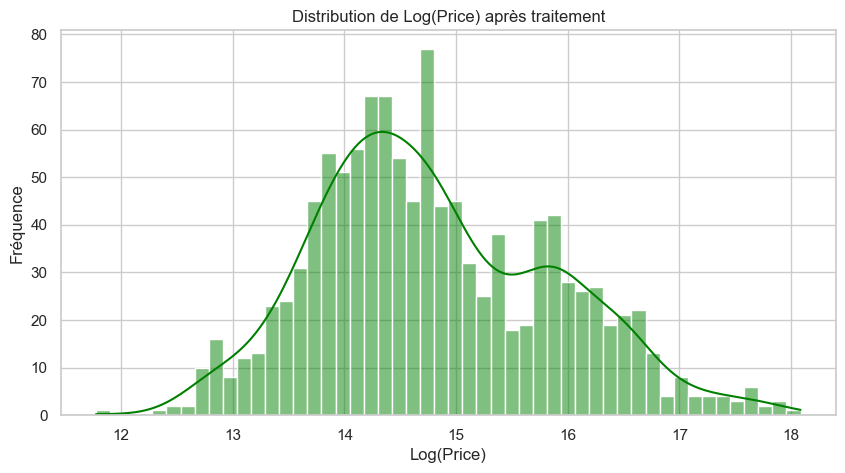

In [105]:
df_vente = df[df['Price'] >= 100000].copy()

df_vente['Price'] = np.log1p(df_vente['Price'])

plt.figure(figsize=(10, 5))
sns.histplot(df_vente['Price'], kde=True, color='green', bins=50)
plt.title("Distribution de Log(Price) après traitement")
plt.xlabel("Log(Price)")
plt.ylabel("Fréquence")
plt.show()

# area cleaning (meme de colonne price)

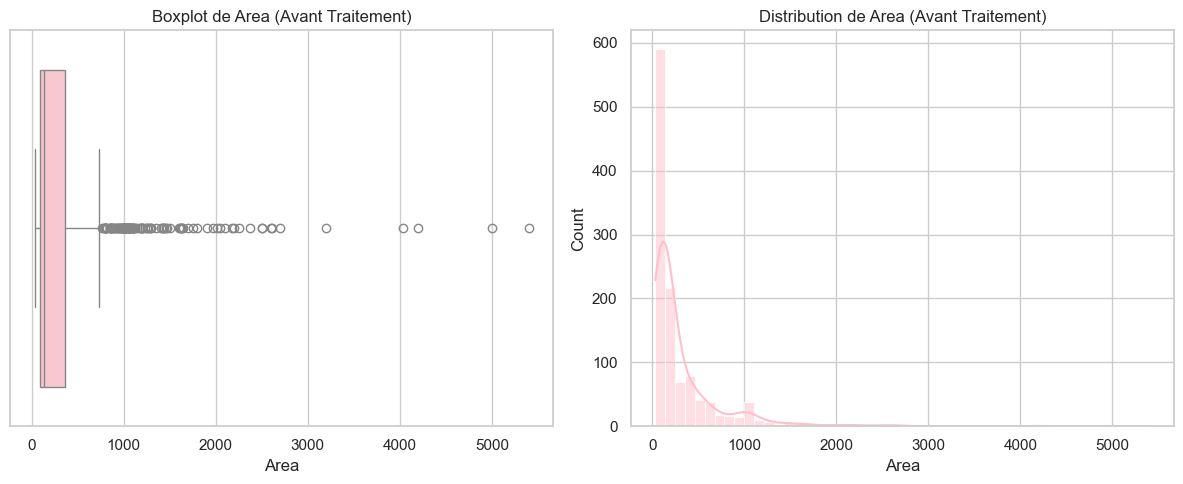

In [106]:
plt.figure(figsize=(12, 5))

# Graphique 1 : Boxplot 
plt.subplot(1, 2, 1)
sns.boxplot(x=df['Area'], color= 'pink')
plt.title('Boxplot de Area (Avant Traitement)')

# Graphique 2 : Histogramme 
plt.subplot(1, 2, 2)
sns.histplot(df['Area'], bins=50, kde=True , color='pink')
plt.title('Distribution de Area (Avant Traitement)')

plt.tight_layout()
plt.show()

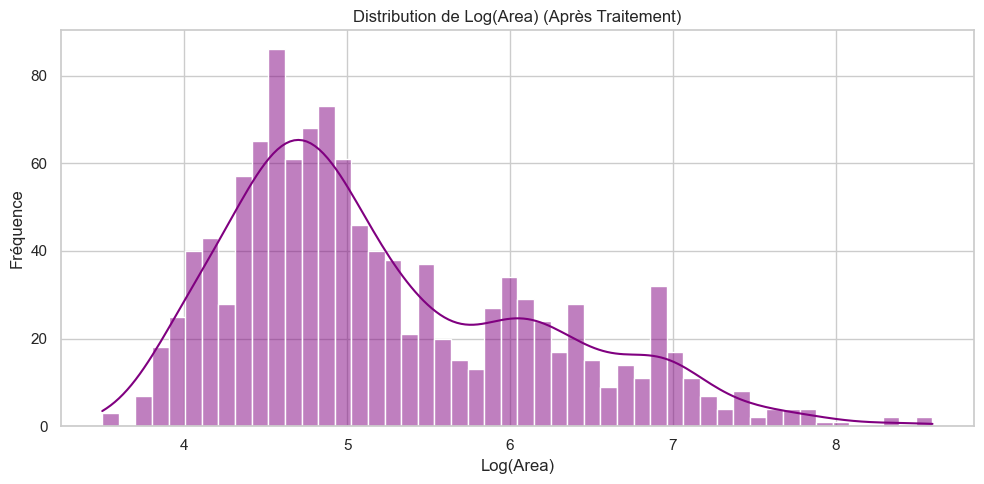

In [107]:
df['Area'] = np.log1p(df['Area'])

# Création du graphique
plt.figure(figsize=(10, 5))
sns.histplot(df['Area'], bins=50, kde=True, color='purple')
plt.title('Distribution de Log(Area) (Après Traitement)')
plt.xlabel('Log(Area)')
plt.ylabel('Fréquence')

plt.tight_layout()
plt.show()

# Rooms cleaning 

Text(0.5, 0, 'Nombre de pièces (avant traitement)')

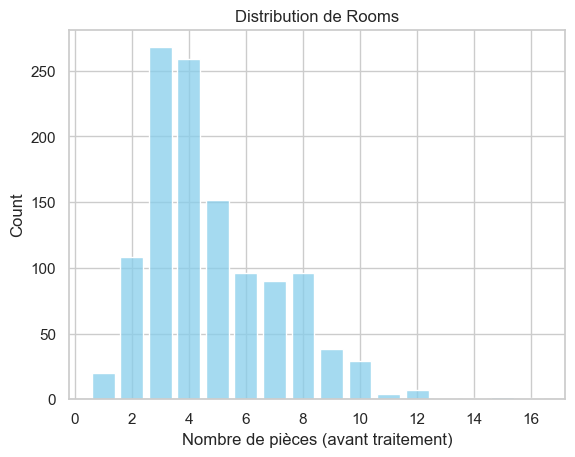

In [108]:
sns.histplot(df['Rooms'], discrete=True, color='skyblue', shrink=0.8)
plt.title('Distribution de Rooms')
plt.xlabel('Nombre de pièces (avant traitement)')

In [109]:
df['Rooms'].value_counts()

Rooms
3.0     268
4.0     259
5.0     152
2.0     108
8.0      96
6.0      96
7.0      90
9.0      38
10.0     29
1.0      20
12.0      7
11.0      4
15.0      2
14.0      1
16.0      1
13.0      1
Name: count, dtype: int64

In [110]:
df['Rooms'] = df['Rooms'].astype(int)

In [111]:
df.loc[df['Rooms'] > 10, 'Rooms'] = 10

In [112]:
print(df['Rooms'].value_counts())

Rooms
3     268
4     259
5     152
2     108
8      96
6      96
7      90
10     45
9      38
1      20
Name: count, dtype: int64


Text(0.5, 0, 'Nombre de pièces (apres traitement)')

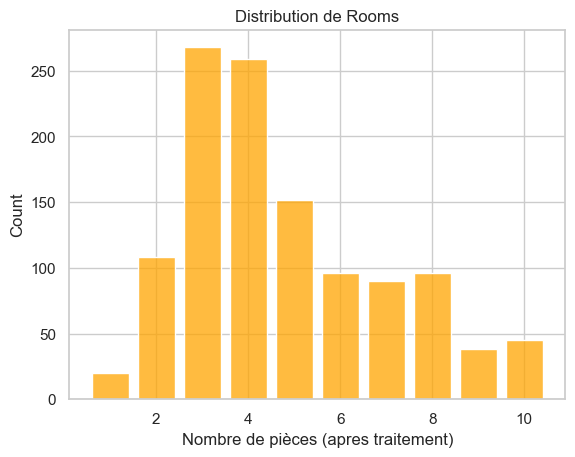

In [113]:
sns.histplot(df['Rooms'], discrete=True, color='orange', shrink=0.8)
plt.title('Distribution de Rooms')
plt.xlabel('Nombre de pièces (apres traitement)')

# Bedrooms cleaning 

Text(0.5, 0, 'Nombre de pièces (avant traitement)')

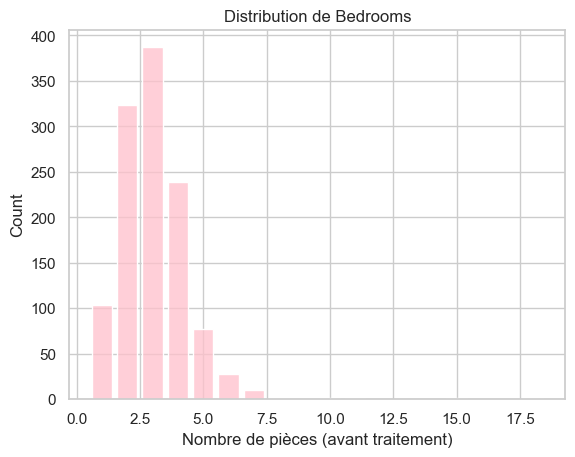

In [114]:
sns.histplot(df['Bedrooms'], discrete=True, color='pink', shrink=0.8)
plt.title('Distribution de Bedrooms')
plt.xlabel('Nombre de pièces (avant traitement)')

In [115]:
df['Bedrooms'].value_counts()

Bedrooms
3.0     387
2.0     323
4.0     239
1.0     103
5.0      77
6.0      28
7.0      10
18.0      1
11.0      1
8.0       1
15.0      1
10.0      1
Name: count, dtype: int64

In [116]:
df['Bedrooms'] = df['Bedrooms'].astype(int)

In [117]:
df.loc[df['Bedrooms'] > 10, 'Bedrooms'] = 10

In [118]:
print(df['Bedrooms'].value_counts())

Bedrooms
3     387
2     323
4     239
1     103
5      77
6      28
7      10
10      4
8       1
Name: count, dtype: int64


Text(0.5, 0, 'Nombre de pièces (apres traitement)')

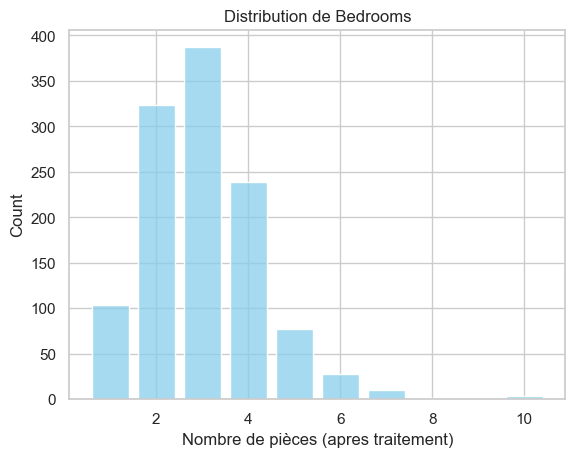

In [119]:
sns.histplot(df['Bedrooms'], discrete=True, color='skyblue', shrink=0.8)
plt.title('Distribution de Bedrooms')
plt.xlabel('Nombre de pièces (apres traitement)')

# Bathrooms cleaning

Text(0.5, 0, 'Nombre de pièces (avant traitement)')

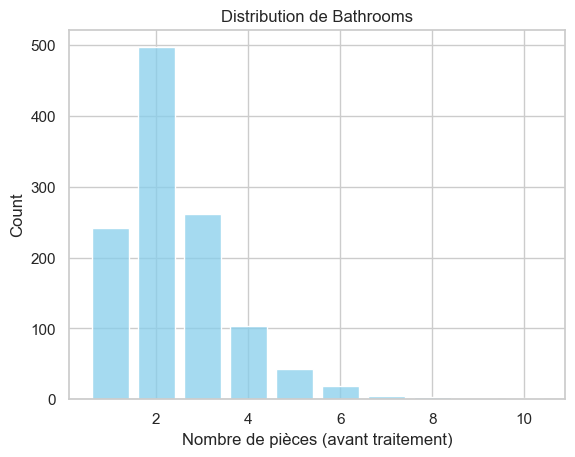

In [120]:
sns.histplot(df['Bathrooms'], discrete=True, color='skyblue', shrink=0.8)
plt.title('Distribution de Bathrooms')
plt.xlabel('Nombre de pièces (avant traitement)')

In [121]:
df['Bathrooms'].value_counts()

Bathrooms
2.0     497
3.0     261
1.0     241
4.0     104
5.0      42
6.0      18
7.0       4
8.0       3
10.0      1
9.0       1
Name: count, dtype: int64

In [122]:
df['Bathrooms'] = df['Bathrooms'].astype(int)

In [123]:
df.loc[df['Bathrooms'] > 10 , 'Bathrooms'] = 10 

In [124]:
print(df['Bathrooms'].value_counts())

Bathrooms
2     497
3     261
1     241
4     104
5      42
6      18
7       4
8       3
10      1
9       1
Name: count, dtype: int64


Text(0.5, 0, 'Nombre de pièces (apres traitement)')

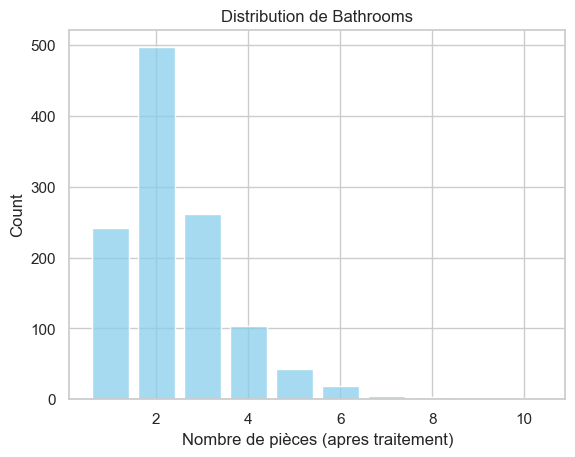

In [125]:
sns.histplot(df['Bathrooms'], discrete=True, color='skyblue', shrink=0.8)
plt.title('Distribution de Bathrooms')
plt.xlabel('Nombre de pièces (apres traitement)')

# Floor cleaning 

Text(0.5, 0, 'Nombre de pièces (avant traitement)')

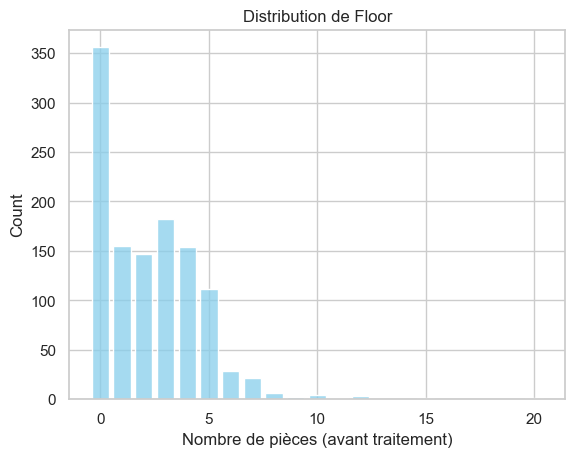

In [126]:
sns.histplot(df['Floor'], discrete=True, color='skyblue', shrink=0.8)
plt.title('Distribution de Floor')
plt.xlabel('Nombre de pièces (avant traitement)')

In [127]:
df['Floor'].value_counts()

Floor
0.0     356
3.0     182
1.0     155
4.0     154
2.0     147
5.0     111
6.0      28
7.0      21
8.0       6
10.0      4
12.0      3
9.0       2
11.0      1
20.0      1
15.0      1
Name: count, dtype: int64

In [128]:
df['Floor'] = df['Floor'].astype(int)

In [129]:
df.loc[df['Floor'] > 10 , 'Floor'] = 10

In [130]:
print(df['Floor'].value_counts())

Floor
0     356
3     182
1     155
4     154
2     147
5     111
6      28
7      21
10     10
8       6
9       2
Name: count, dtype: int64


Text(0.5, 0, 'Nombre de pièces (apres traitement)')

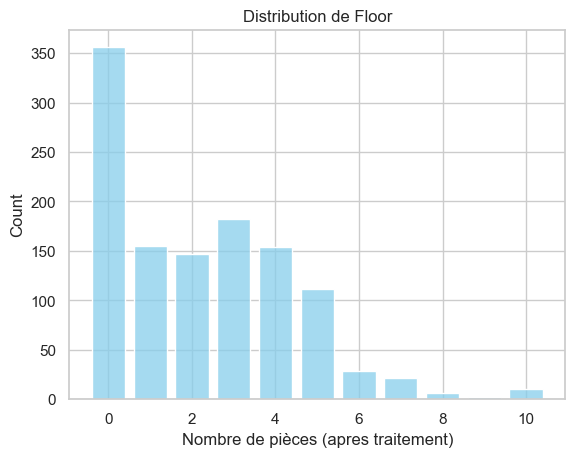

In [131]:
sns.histplot(df['Floor'], discrete=True, color='skyblue', shrink=0.8)
plt.title('Distribution de Floor')
plt.xlabel('Nombre de pièces (apres traitement)')

# Price_m2 cleaning 

### verefication de coherence 

In [132]:
prix_calcule = round(df['Price'] / df['Area'], 2)
prix_existant = round(df['Price_m2'], 2)

lignes_incoherentes = df[prix_calcule != prix_existant]

print(f"combien des lignes ont des erreurs : {len(lignes_incoherentes)}")

if len(lignes_incoherentes) > 0:
    print(lignes_incoherentes[['Price', 'Area', 'Price_m2']].head())

combien des lignes ont des erreurs : 1172
     Price      Area      Price_m2
0    22000  5.393628    100.456621
1  1230000  4.465908  14302.325581
2   900000  4.465908  10465.116279
3  2400000  5.198497  13333.333333
4  1550000  4.795791  12916.666667


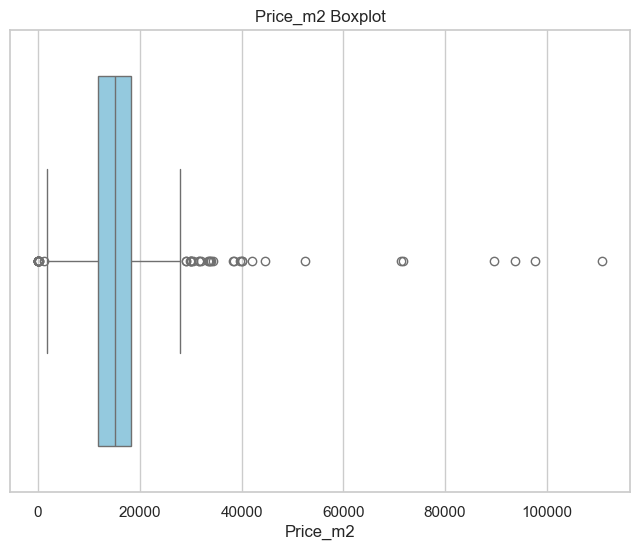

In [133]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Price_m2'], color='skyblue')
plt.title("Price_m2 Boxplot")
plt.xlabel("Price_m2")
plt.show()

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">4- Analyse Exploratoire des Données</h2>
</div>

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1172 entries, 0 to 1171
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Type           1172 non-null   object 
 1   Localisation   1172 non-null   object 
 2   Price          1172 non-null   int64  
 3   Area           1172 non-null   float64
 4   Rooms          1172 non-null   int32  
 5   Bedrooms       1172 non-null   int32  
 6   Bathrooms      1172 non-null   int32  
 7   Floor          1172 non-null   int32  
 8   Other_tags     1172 non-null   object 
 9   Price_m2       1172 non-null   float64
 10  Current_state  1123 non-null   object 
 11  Age            882 non-null    object 
dtypes: float64(2), int32(4), int64(1), object(5)
memory usage: 91.7+ KB


In [135]:
cols_to_keep = ['Type','Localisation','Area','Rooms','Bedrooms','Bathrooms','Floor','Current_state','Age','Price']
df_model = df[cols_to_keep]

In [136]:
display(df_model.isna().sum())

Type               0
Localisation       0
Area               0
Rooms              0
Bedrooms           0
Bathrooms          0
Floor              0
Current_state     49
Age              290
Price              0
dtype: int64

In [137]:
features = ['Type','Localisation','Area','Rooms','Bedrooms','Bathrooms','Floor','Current_state','Age']
X = df_model[features]
y = df_model['Price'].values 

In [138]:
cols_to_impute = ['Current_state', 'Age']

df_model = df_model.copy()
encoder = OrdinalEncoder()
df_model[cols_to_impute] = encoder.fit_transform(df_model[cols_to_impute])

numeric_cols = ['Area', 'Rooms', 'Bedrooms', 'Bathrooms', 'Floor', 'Current_state', 'Age']
df_model = df_model[numeric_cols]

imputer = KNNImputer(n_neighbors=5, weights='distance')
df_knn_imputed = pd.DataFrame(imputer.fit_transform(df_model), columns=numeric_cols)

df_model['Current_state'] = df_knn_imputed['Current_state']
df_model['Age'] = df_knn_imputed['Age']

df_model[cols_to_impute] = encoder.inverse_transform(df_model[cols_to_impute])

print("Les valeurs manquantes b3d KNNImputer:")
display(df_model.isna().sum())

Les valeurs manquantes b3d KNNImputer:


Area             0
Rooms            0
Bedrooms         0
Bathrooms        0
Floor            0
Current_state    0
Age              0
dtype: int64

In [139]:
x = pd.get_dummies(X)

In [140]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size = 0.3,random_state = 123)

In [141]:
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train),columns = X_train.columns)
X_test_scaled = pd.DataFrame(scaler.fit_transform(X_test),columns = X_test.columns)

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">5- Prétraitement des Données</h2>
</div>

<div style="background-color: #c8e0f3; color: #333333; padding: 20px; border-radius: 8px; border: 1px solid #e0e0e0; font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; margin-bottom: 15px;">
    <h2 style="color: #1e3a8a; border-bottom: 2px solid #3b82f6; padding-bottom: 8px; margin-top: 0; font-size: 1.5rem; text-align: center; font-weight: bold;">6- Modélisation</h2>
</div>

In [147]:
import pandas as pd
import numpy as np
import math
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Importation dyal les modèles
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

def optimize_models_anti_overfitting(X_train, X_test, y_train, y_test):
    # Dictionnaire fih l'Pipelines (Scaling) w l'Hyperparamètres Anti-Overfitting
    models_grids = {
        "Ridge (Scaled)": {
            "model": Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())]),
            "params": {"ridge__alpha": [1.0, 10.0, 50.0, 100.0]}
        },
        "Lasso (Scaled)": {
            "model": Pipeline([("scaler", StandardScaler()), ("lasso", Lasso())]),
            "params": {"lasso__alpha": [0.001, 0.01, 0.1, 1.0]}
        },
        "KNN (Scaled)": {
            "model": Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor())]),
            "params": {
                "knn__n_neighbors": [5, 9, 15], 
                "knn__weights": ['uniform'] # 'distance' hya li kant dayra lik 1.0 f Train
            }
        },
        "SVR (Scaled)": {
            "model": Pipeline([("scaler", StandardScaler()), ("svr", SVR())]),
            "params": {
                "svr__kernel": ['rbf'], 
                "svr__C": [0.1, 1.0, 10.0], 
                "svr__epsilon": [0.01, 0.1]
            }
        },
        "Decision Tree": {
            "model": DecisionTreeRegressor(random_state=42),
            "params": {
                "max_depth": [4, 6, 8], 
                "min_samples_split": [10, 20], 
                "min_samples_leaf": [5, 10]
            }
        },
        "Random Forest": {
            "model": RandomForestRegressor(random_state=42, n_jobs=-1),
            "params": {
                "n_estimators": [100, 200], 
                "max_depth": [5, 8, 10], 
                "min_samples_split": [10, 15], 
                "min_samples_leaf": [5, 10]
            }
        },
        "Gradient Boosting": {
            "model": GradientBoostingRegressor(random_state=42),
            "params": {
                "n_estimators": [100, 200], 
                "learning_rate": [0.01, 0.05], 
                "max_depth": [3, 5]
            }
        },
        "XGBoost": {
            "model": XGBRegressor(random_state=42, n_jobs=-1),
            "params": {
                "n_estimators": [100, 200], 
                "learning_rate": [0.01, 0.05], 
                "max_depth": [3, 5], 
                "subsample": [0.7, 0.8], 
                "colsample_bytree": [0.7, 0.8]
            }
        },
        "CatBoost": {
            "model": CatBoostRegressor(verbose=0, random_state=42),
            "params": {
                "iterations": [200, 500], 
                "learning_rate": [0.01, 0.05], 
                "depth": [4, 6], 
                "l2_leaf_reg": [5, 10, 20] # Zidna f l'pénalité bach may7fdch
            }
        }
    }
    
    results = []
    best_models_dict = {}
    
    for name, config in models_grids.items():
        print(f"⏳ Optimisation en cours pour : {name}...")
        
        # GridSearchCV m3a 5-Fold Cross Validation
        grid_search = GridSearchCV(
            estimator=config["model"],
            param_grid=config["params"],
            scoring='r2',
            cv=5,
            n_jobs=-1
        )
        
        # L'entrainement
        grid_search.fit(X_train, y_train)
        
        # L'extraction dyal a7san modèle
        best_model = grid_search.best_estimator_
        best_models_dict[name] = best_model
        
        # Les prédictions
        y_train_pred = best_model.predict(X_train)
        y_test_pred = best_model.predict(X_test)
        
        # L'évaluation
        results.append({
            "Modèle": name,
            "R2 Score (Train)": round(r2_score(y_train, y_train_pred), 4),
            "R2 Score (Test)": round(r2_score(y_test, y_test_pred), 4),
            "RMSE": round(math.sqrt(mean_squared_error(y_test, y_test_pred)), 4),
            "MAE": round(mean_absolute_error(y_test, y_test_pred), 4),
            "Meilleurs Paramètres": str(grid_search.best_params_)
        })
        
    # Ta7wil l'résultats l DataFrame
    df_results = pd.DataFrame(results).sort_values(by="R2 Score (Test)", ascending=False).reset_index(drop=True)
    
    print("\n✅ L'optimisation salat ! Hada l'classement jdid:")
    return df_results, best_models_dict

# Appel dyal la fonction:
# tableau_final, meilleurs_modeles = optimize_models_anti_overfitting(X_train, X_test, y_train, y_test)
# display(tableau_final)

In [ ]:
tableau_final, meilleurs_modeles = optimize_models_anti_overfitting(X_train, X_test, y_train, y_test)

display(tableau_final)



⏳ Optimisation en cours pour : Ridge (Scaled)...
⏳ Optimisation en cours pour : Lasso (Scaled)...


c:\Users\Pc\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.663e+14, tolerance: 4.275e+12
  model = cd_fast.enet_coordinate_descent(


⏳ Optimisation en cours pour : KNN (Scaled)...
⏳ Optimisation en cours pour : SVR (Scaled)...
⏳ Optimisation en cours pour : Decision Tree...
⏳ Optimisation en cours pour : Random Forest...
⏳ Optimisation en cours pour : Gradient Boosting...
⏳ Optimisation en cours pour : XGBoost...
⏳ Optimisation en cours pour : CatBoost...

✅ L'optimisation salat ! Hada l'classement jdid:


,Modèle,R2 Score (Train),R2 Score (Test),RMSE,MAE,Meilleurs Paramètres
0,CatBoost,0.9753,0.8055,3.437222e+06,1.103661e+06,"{'depth': 4, 'iterations': 500, 'l2_leaf_reg':..."
1,Gradient Boosting,0.9724,0.7973,3.508916e+06,1.170525e+06,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est..."
2,XGBoost,0.9640,0.7750,3.696921e+06,1.225341e+06,"{'colsample_bytree': 0.8, 'learning_rate': 0.0..."
3,Decision Tree,0.8947,0.7357,4.006738e+06,1.339302e+06,"{'max_depth': 8, 'min_samples_leaf': 10, 'min_..."
4,Random Forest,0.9072,0.7277,4.066567e+06,1.316877e+06,"{'max_depth': 5, 'min_samples_leaf': 5, 'min_s..."
5,Ridge (Scaled),0.7777,0.6364,4.699735e+06,2.156473e+06,{'ridge__alpha': 50.0}
6,Lasso (Scaled),0.7863,0.6364,4.699738e+06,2.271826e+06,{'lasso__alpha': 1.0}
7,KNN (Scaled),0.7472,0.5833,5.031258e+06,2.164472e+06,"{'knn__n_neighbors': 5, 'knn__weights': 'unifo..."
8,SVR (Scaled),-0.1220,-0.1288,8.280476e+06,3.924390e+06,"{'svr__C': 10.0, 'svr__epsilon': 0.1, 'svr__ke..."


In [149]:
best_catboost = meilleurs_modeles["CatBoost"]

In [152]:
joblib.dump(best_catboost, 'modele_MaisonDeLUX.pkl')

['modele_MaisonDeLUX.pkl']